## The goal is to come up with a predictive model which helps prioritize quotes with highest chance of cross selling the product

  ### Case Details: 
  
  #### Existing customers have been quoted for "Product X" and the status of each quote is marked as Sold or Lost. The relavent data is stored in three files: 
  #### 1. `employers.csv` - holds basic customer data, such as number of years as a client, number of employees and Industry type. 
  #### 2. `geography.csv` - contains general geographic location by zip code, such as longitude, latitude, population etc... 
  #### 3. `quotes.csv` - contains the quote status (lost or sold) by the customer's ID. 
  #### 4. `dictionary.csv` - contains additional information on what each data set contains  

In [205]:
!pip install scikit-learn

In [206]:
# Import Packages

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans


from scipy import stats
from scipy.stats import norm, skew




In [207]:
# Load Data
employer_data = pd.read_csv("data/employers.csv", encoding="cp1252")
geography_data = pd.read_csv("data/geography.csv", encoding="cp1252")
quotes_data = pd.read_csv("data/quotes.csv", encoding="cp1252")


### Data Cleaning

In [208]:
# Inspect employer table
employer_data.info()
employer_data.head()

# Check for duplicates
employer_data["EmployerId"].duplicated().sum()
dupe_employers =employer_data[employer_data["EmployerId"].duplicated(keep=False)].sort_values("EmployerId")
dupe_employers

#Then check whether only Industry differs or other columns differ too
dupe_employers.groupby("EmployerId").nunique()

# More focused duplicates
dupe_employers.groupby("EmployerId")["Industry"].unique()

# Keep the first occurrence of each duplicate and drop the rest
employer_data_clean = employer_data.drop_duplicates(subset="EmployerId", keep="first")

# Create a new dataframe with the count of unique industries per employer for feature engineering
industry_counts = (
    employer_data
    .groupby("EmployerId")["Industry"]
    .nunique()
    .reset_index(name="industry_count")
)


<class 'pandas.DataFrame'>
RangeIndex: 65356 entries, 0 to 65355
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   EmployerId       65356 non-null  int64
 1   ClientTenure     65356 non-null  int64
 2   Employees        65356 non-null  int64
 3   Industry         57125 non-null  str  
 4   NetworkStrength  65356 non-null  str  
 5   ZipCode          65356 non-null  str  
dtypes: int64(3), str(3)
memory usage: 3.0 MB


In [209]:
geography_data.info()

# Check for duplicates
geography_data["zip"].duplicated().sum()
#geography_data[geography_data["zip"].duplicated(keep=False)].sort_values("zip")

<class 'pandas.DataFrame'>
RangeIndex: 43318 entries, 0 to 43317
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   zip         43318 non-null  int64  
 1   city        43318 non-null  str    
 2   latitude    43318 non-null  float64
 3   longitude   43318 non-null  float64
 4   fips        43318 non-null  int64  
 5   county      43318 non-null  str    
 6   population  43318 non-null  int64  
 7   state       43318 non-null  str    
 8   cbsa        43318 non-null  str    
 9   cbsa_name   43318 non-null  str    
dtypes: float64(2), int64(3), str(5)
memory usage: 3.3 MB


np.int64(0)

In [210]:
quotes_data.info()

# Check for duplicates
quotes_data["EmployerId"].duplicated().sum()
quotes_data[quotes_data["EmployerId"].duplicated(keep=False)].sort_values("EmployerId")

# Remove duplicates from quotes data
quotes_data_clean = quotes_data.drop_duplicates(
    subset=["EmployerId"],
    keep="first"
)
quotes_data_clean["EmployerId"].duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7398 entries, 0 to 7397
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   EmployerId  7398 non-null   int64
 1   Offered     7398 non-null   str  
 2   Status      7398 non-null   str  
dtypes: int64(1), str(2)
memory usage: 173.5 KB


np.int64(0)

In [213]:
#Change Zipcode columns to same name in both tables
geography_data.rename(columns={"zip": "ZipCode"}, inplace=True)

# Change merge columns to same Dtypes (numeric)
employer_data_clean["ZipCode"] = pd.to_numeric(
    employer_data_clean["ZipCode"],
    errors="coerce"
).astype("Int64")

In [216]:
# Merge Dataframes
data = (quotes_data_clean.merge(employer_data_clean, on="EmployerId", how="left").merge(geography_data, on="ZipCode", how="left"))
data.head()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7396 entries, 0 to 7395
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   EmployerId       7396 non-null   int64  
 1   Offered          7396 non-null   str    
 2   Status           7396 non-null   str    
 3   ClientTenure     7396 non-null   int64  
 4   Employees        7396 non-null   int64  
 5   Industry         5998 non-null   str    
 6   NetworkStrength  7396 non-null   str    
 7   ZipCode          7389 non-null   Int64  
 8   city             7377 non-null   str    
 9   latitude         7377 non-null   float64
 10  longitude        7377 non-null   float64
 11  fips             7377 non-null   float64
 12  county           7377 non-null   str    
 13  population       7377 non-null   float64
 14  state            7377 non-null   str    
 15  cbsa             7377 non-null   str    
 16  cbsa_name        7377 non-null   str    
dtypes: Int64(1), float64(4), 

In [217]:
# Remove Null values
data_clean = data.dropna()
data_clean.info()

<class 'pandas.DataFrame'>
Index: 5984 entries, 0 to 7395
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   EmployerId       5984 non-null   int64  
 1   Offered          5984 non-null   str    
 2   Status           5984 non-null   str    
 3   ClientTenure     5984 non-null   int64  
 4   Employees        5984 non-null   int64  
 5   Industry         5984 non-null   str    
 6   NetworkStrength  5984 non-null   str    
 7   ZipCode          5984 non-null   Int64  
 8   city             5984 non-null   str    
 9   latitude         5984 non-null   float64
 10  longitude        5984 non-null   float64
 11  fips             5984 non-null   float64
 12  county           5984 non-null   str    
 13  population       5984 non-null   float64
 14  state            5984 non-null   str    
 15  cbsa             5984 non-null   str    
 16  cbsa_name        5984 non-null   str    
dtypes: Int64(1), float64(4), int64

In [218]:
# Normalize column names
data_clean.columns = data.columns.str.lower()

# Normalize rows
data_clean["county"] = data_clean["county"].str.replace(" ", "_")
data_clean.head()

,employerid,offered,status,clienttenure,employees,industry,networkstrength,zipcode,city,latitude,longitude,fips,county,population,state,cbsa,cbsa_name
0,363773443,ProductX,Lost,4,55,I26,0.1011,77075,Houston,29.620881,-95.26018,48201.0,Harris_County,4092459.0,TX,26420,Houston-The Woodlands-Sugar Land
1,186941116,ProductX,Lost,5,10,I12,-0.0333,6002,Bloomfield,41.832798,-72.72642,9003.0,Hartford_County,894014.0,CT,25540,Hartford-West Hartford-East Hartford
2,511147993,ProductX,Lost,10,48,I19,0.8138,30067,Marietta,33.933002,-84.47633,13067.0,Cobb_County,688078.0,GA,12060,Atlanta-Sandy Springs-Roswell
3,46777684,ProductX,Lost,6,26,I20,-0.1963,2886,Warwick,41.705478,-71.45119,44003.0,Kent_County,166158.0,RI,39300,Providence-Warwick
4,115068663,ProductX,Lost,6,64,I27,0.1815,60440,Bolingbrook,41.703097,-88.07462,17197.0,Will_County,677560.0,IL,16980,Chicago-Naperville-Elgin


In [ ]:
# Convert networkstrength to numeric
data_clean["networkstrength"] = pd.to_numeric(data_clean["networkstrength"], errors="coerce")

# Check for non-numeric values in networkstrength
bad_networkstrength = data_clean[
    pd.to_numeric(data_clean["networkstrength"], errors="coerce").isna()
]
bad_networkstrength["networkstrength"].value_counts(dropna=False)

networkstrength
NaN    49
Name: count, dtype: int64

In [220]:
# Encode the target variable
data_clean["status"].unique()
data_clean["status"] = data_clean["status"].str.strip().str.lower()
data_clean["status"] = data_clean["status"].map({"sold": 1, "lost": 0})
data_clean.head()

,employerid,offered,status,clienttenure,employees,industry,networkstrength,zipcode,city,latitude,longitude,fips,county,population,state,cbsa,cbsa_name
0,363773443,ProductX,0,4,55,I26,0.1011,77075,Houston,29.620881,-95.26018,48201.0,Harris_County,4092459.0,TX,26420,Houston-The Woodlands-Sugar Land
1,186941116,ProductX,0,5,10,I12,-0.0333,6002,Bloomfield,41.832798,-72.72642,9003.0,Hartford_County,894014.0,CT,25540,Hartford-West Hartford-East Hartford
2,511147993,ProductX,0,10,48,I19,0.8138,30067,Marietta,33.933002,-84.47633,13067.0,Cobb_County,688078.0,GA,12060,Atlanta-Sandy Springs-Roswell
3,46777684,ProductX,0,6,26,I20,-0.1963,2886,Warwick,41.705478,-71.45119,44003.0,Kent_County,166158.0,RI,39300,Providence-Warwick
4,115068663,ProductX,0,6,64,I27,0.1815,60440,Bolingbrook,41.703097,-88.07462,17197.0,Will_County,677560.0,IL,16980,Chicago-Naperville-Elgin


<Axes: >

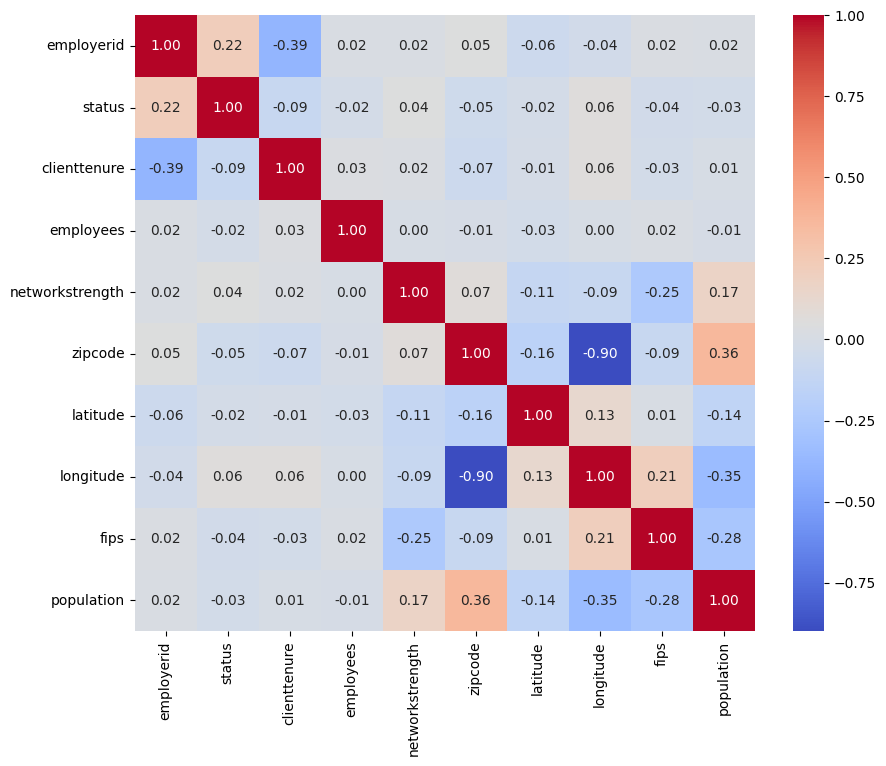

In [222]:
# Numeric feature correlation to target variable
numeric_features = data_clean.select_dtypes(include=[np.number])
correlation_matrix = numeric_features.corr()
correlation_matrix["status"].sort_values(ascending=False)

# Graph the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

### Split the data

In [ ]:
# Check the distribution of the target variable
print(data_clean["status"].value_counts()) # target is imbalanced with more results in the lost category than sold

# Remove obvious columns that won't be used in modeling
drop_cols = [
    "status",      # target
    "employerid",  # ID, not a real predictive feature
    "zipcode",     # location code, not usually meaningful as a number
    "fips"         # another geographic code
]

# Test train split
X = data_clean.drop(columns=drop_cols)
y = data_clean["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

status
0    4841
1    1143
Name: count, dtype: int64


### Preprocessing

In [ ]:
# Import packages for modeling
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# Install xgboost if it's not already installed
#!pip install xgboost
from xgboost import XGBClassifier


In [232]:
# Define numeric and categorical features for preprocessing
numeric_features = ["clienttenure", "employees", "networkstrength", "latitude", "longitude", "population"]

categorical_features = ["industry", "state", "county", "cbsa", "cbsa_name"]

In [233]:
# Create separate preprocessors for one-hot encoding and ordinal encoding
onehot_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

ordinal_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OrdinalEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
# Define models with different preprocessing techniques and their hyperparameters for tuning
experiment_models = {
    "logreg_onehot": {
        "pipeline": Pipeline([
            ("preprocessor", onehot_preprocessor),
            ("model", LogisticRegression(max_iter=1000))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["lbfgs"]
        }
    },

    "random_forest": {
        "pipeline": Pipeline([
            ("preprocessor", ordinal_preprocessor),
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [200, 500],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_leaf": [1, 2, 5]
        }
    },

    "xgboost": {
        "pipeline": Pipeline([
            ("preprocessor", ordinal_preprocessor),
            ("model", XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 500],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [3, 5],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    }
}

In [238]:
# Loop through models and perform RandomizedSearchCV for hyperparameter tuning
results = {}

for name, config in experiment_models.items():
    print(f"Training {name}...")

    random_search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=25,
        cv=5,
        scoring="roc_auc",
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    results[name] = {
        "best_score": random_search.best_score_,
        "best_params": random_search.best_params_,
        "best_model": random_search.best_estimator_
    }

Training logreg_onehot...


c:\Users\exi0\.conda\envs\ml-zoomcamp\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=25. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


ValueError: 
All the 20 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\exi0\.conda\envs\ml-zoomcamp\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\exi0\.conda\envs\ml-zoomcamp\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\exi0\.conda\envs\ml-zoomcamp\Lib\site-packages\sklearn\pipeline.py", line 621, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "c:\Users\exi0\.conda\envs\ml-zoomcamp\Lib\site-packages\sklearn\base.py", line 1336, 